# Vibration Analysis Walkthrough

This notebook documents the exploratory analysis and anomaly-detection modeling built on top of `scripts/analyse_data.py`, for the vibration dataset from a Kapp KX260 Twin grinding machine (4 sensors, 5 worksteps, FFT spectra at 6.10 Hz resolution).

Every figure below is produced by calling the actual functions from that module — this notebook is a narrated tour of the analysis (what was looked at, why, and what design choices were made and why), not a separate reimplementation. See `results.md` for the condensed write-up and `notebooks/wasserstein_distance.ipynb` for background on the Wasserstein distance used throughout.

In [1]:
import sys
sys.path.append("..")

import pandas as pd

import scripts.analyse_data as ad

%matplotlib inline

## 1. Data overview

The combined dataset (`data/processed/combined_measurements.parquet`, built by `scripts/data_preprocessing.py`) has one row per FFT spectrum. Before looking at any spectra, it's worth checking what the metadata actually says — this shapes every decision that follows.

In [2]:
data = pd.read_parquet("../data/processed/combined_measurements.parquet")
print(f"{len(data):,} rows, sensors={sorted(data['sensor'].unique())}, worksteps={sorted(data['workstep'].unique())}")
data.groupby(["sensor", "workstep"])["Alarmlevel"].unique()

187,977 rows, sensors=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)], worksteps=[np.int64(3), np.int64(111), np.int64(199), np.int64(211), np.int64(299)]


sensor  workstep
1       3           [-1]
        111          [0]
        199          [0]
        211          [0]
        299          [0]
2       3           [-1]
        111         [-1]
        199         [-1]
        211         [-1]
        299         [-1]
3       3           [-1]
        111         [-1]
        199         [-1]
        211         [-1]
        299         [-1]
4       3           [-1]
        111         [-1]
        199         [-1]
        211         [-1]
        299         [-1]
Name: Alarmlevel, dtype: object

This is the first, and arguably most important, finding: `Alarmlevel` is `0` (evaluated, in-spec) only for sensor 1 at worksteps 111/199/211/299. Every other combination — including sensor 1 at workstep 3 — is `-1`. Checking the raw CSVs directly (lines 33-34 of each file) confirms why: those are the machine's own `WARNING`/`ERROR` threshold rows, and for every sensor except sensor 1 they read literally `no Reference` / `no Limit` — no threshold was ever configured for them.

**This rules out `Alarmlevel` as a usable anomaly ground truth**: it reflects which sensor happens to be wired into the machine's own supervision, not actual vibration severity. It also explains why workstep 3 (the warmup step) has no reference for anyone. This single finding drives the self-generated labeling approach in section 6.

Raw `Wert*` amplitudes also span about three orders of magnitude, and `Wert1` (the DC bin) is constant zero — so every function below works in dB (`ad.to_db`, `20*log10`) and drops the DC bin (`ad._spectrum_cols`).

## 2. Time-frequency behavior (spectrograms)

Given only sensor 1 ever reaches `Alarmlevel=0`, plotting spectrograms at that level directly visualizes the supervision asymmetry above — sensor rows 2-4 come back empty, which is itself the finding, not a bug.

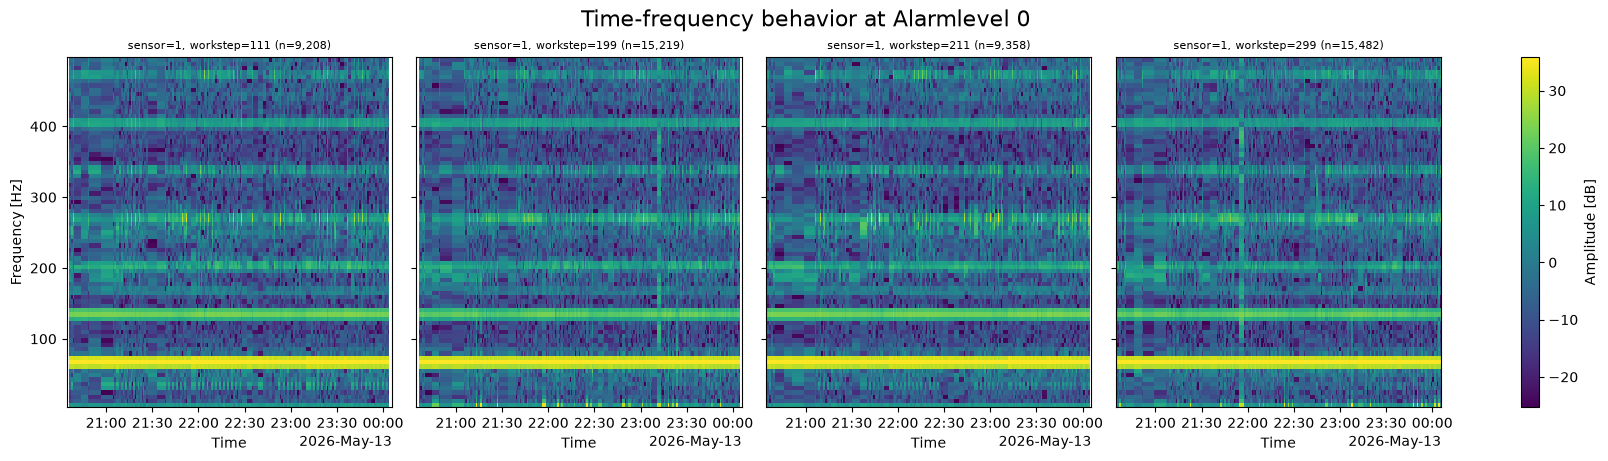

In [3]:
ad.plot_spectrograms_by_group(data, alarmlevel=0, max_frequency_hz=500)

A Mel-scale version (a real triangular filterbank applied to the power spectrum, not just an axis warp) expands resolution at low frequency and compresses it at high — most of the harmonic structure of interest lives below ~300 Hz, so this trades away detail we don't need for detail we do.

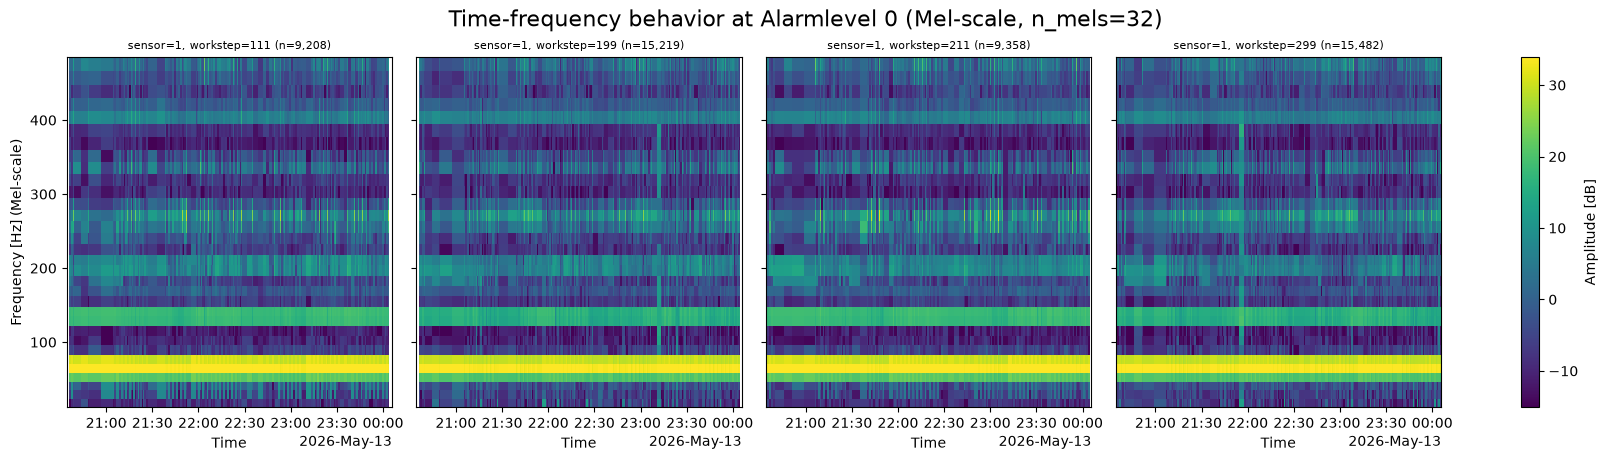

In [4]:
ad.plot_spectrograms_by_group_mel(data, alarmlevel=0, max_frequency_hz=500)

## 3. Mean spectra and harmonic structure

Mean ± std spectra per sensor, faceted by workstep, in dB — raw amplitude has too wide a dynamic range (and level differences between sensor/workstep) to average meaningfully otherwise.

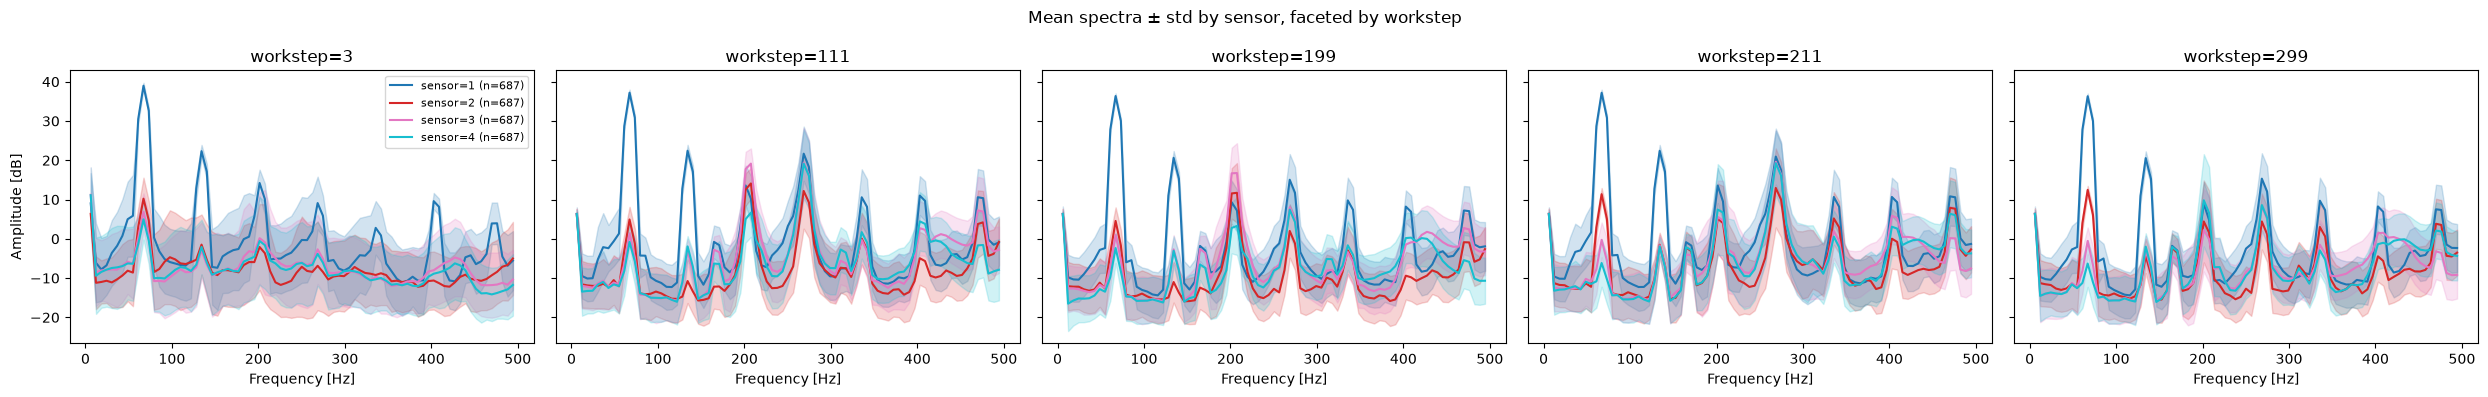

In [5]:
ad.plot_mean_spectra(data, error="std", max_frequency_hz=500)

Every panel shows a sharp, evenly-spaced comb of peaks. `ad.detect_harmonics` fits a fundamental frequency by testing candidate peaks and counting how many others land on integer multiples of each candidate, then classifies every detected peak as harmonic (green) or not (red). Running it per sensor+workstep group:

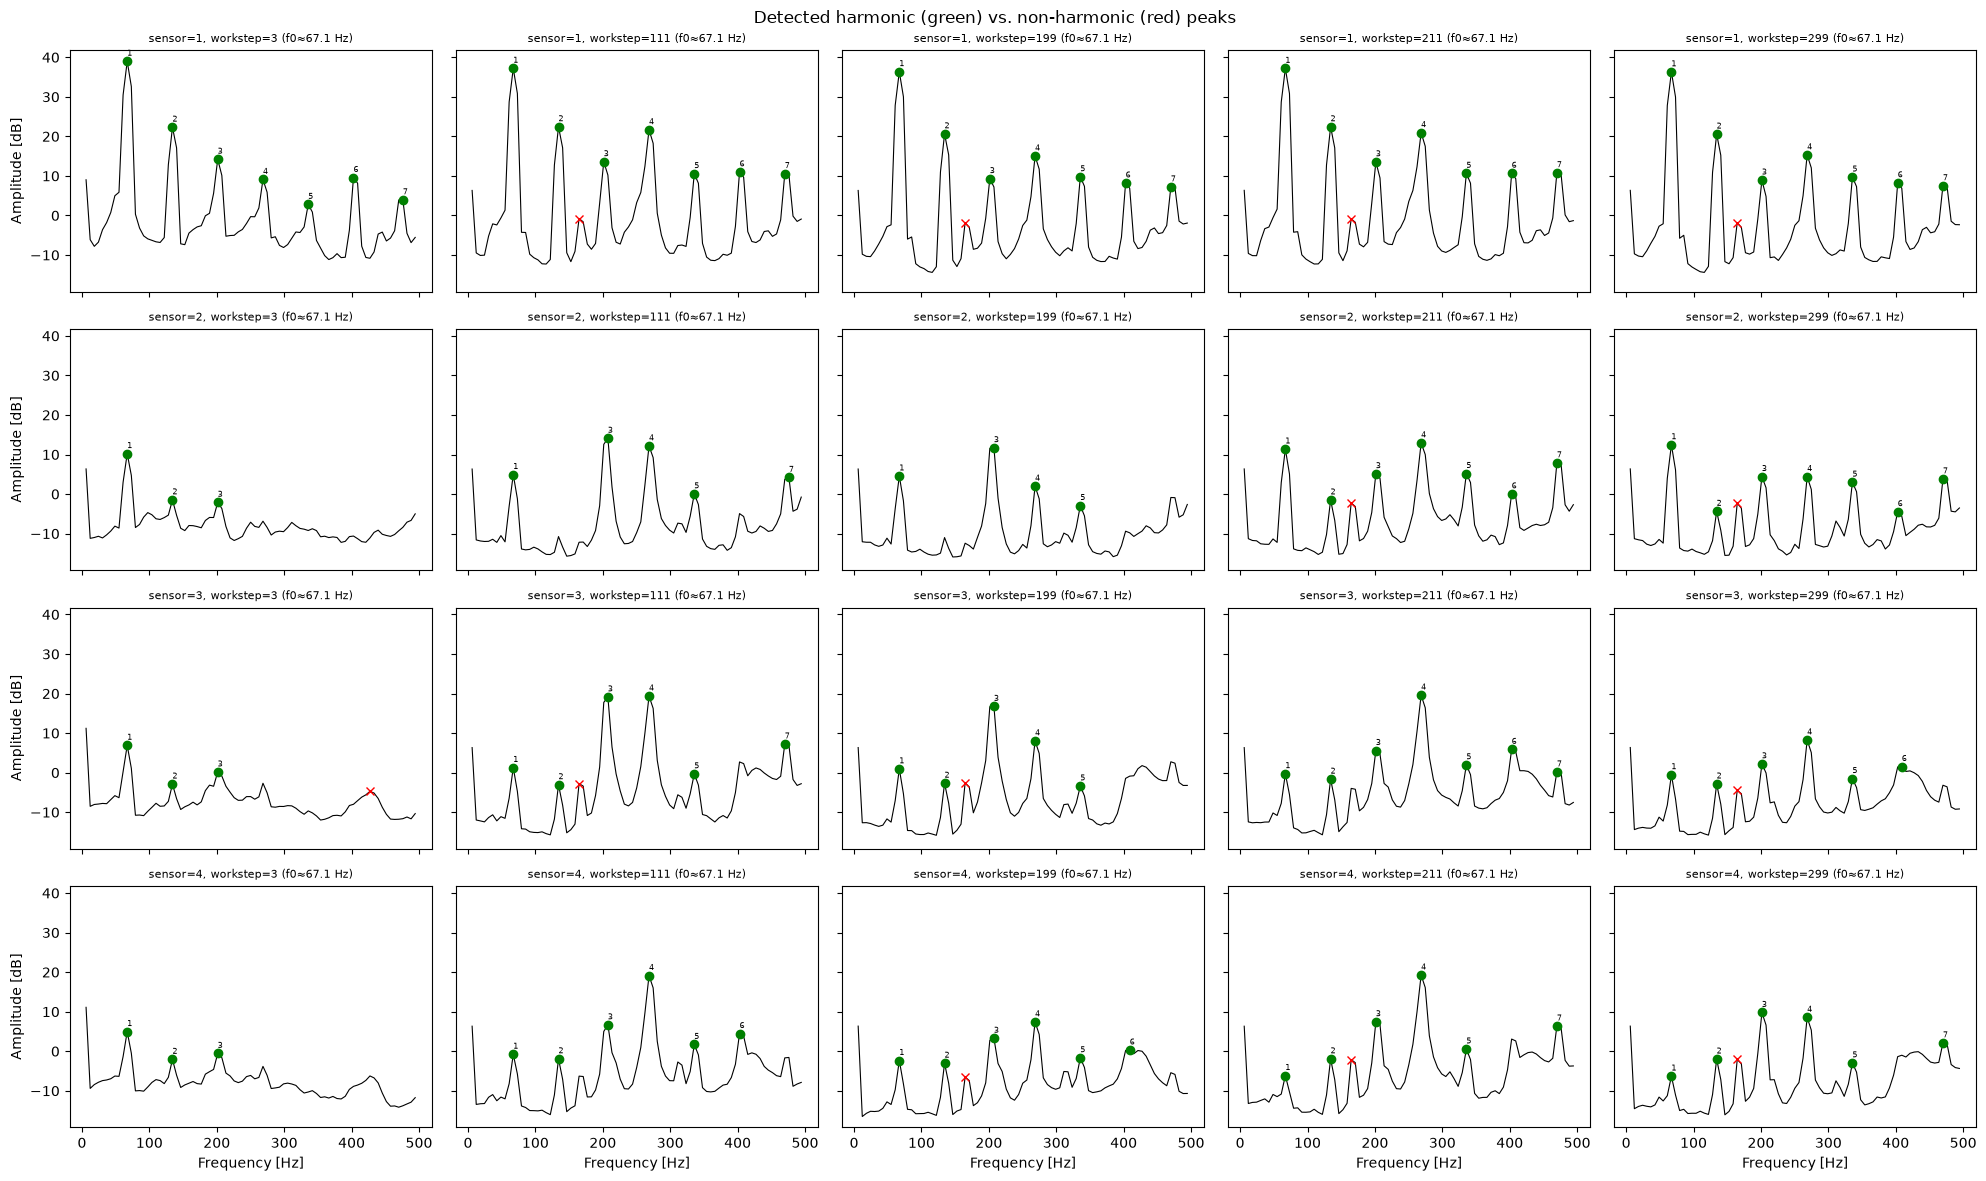

In [6]:
ad.plot_harmonic_peaks(data, max_frequency_hz=500)

**f0 ≈ 67.1 Hz in every one of the 20 sensor+workstep groups** — that consistency across 20 independent groups is strong evidence of one shared mechanical rotational source, not coincidence or a curve-fitting artifact.

Peak amplitude does *not* decay monotonically with harmonic order, but that's expected rather than disqualifying: real amplitude is shaped by the structure's transfer function (bearing/spindle-housing resonances), not an intrinsic 1/n decay — the right test for harmonicity is frequency-spacing consistency, which held. There's a shared resonance bump around harmonic order 3-4 (~200-270 Hz) visible across *all* sensors, independent of the sensor-1 finding below.

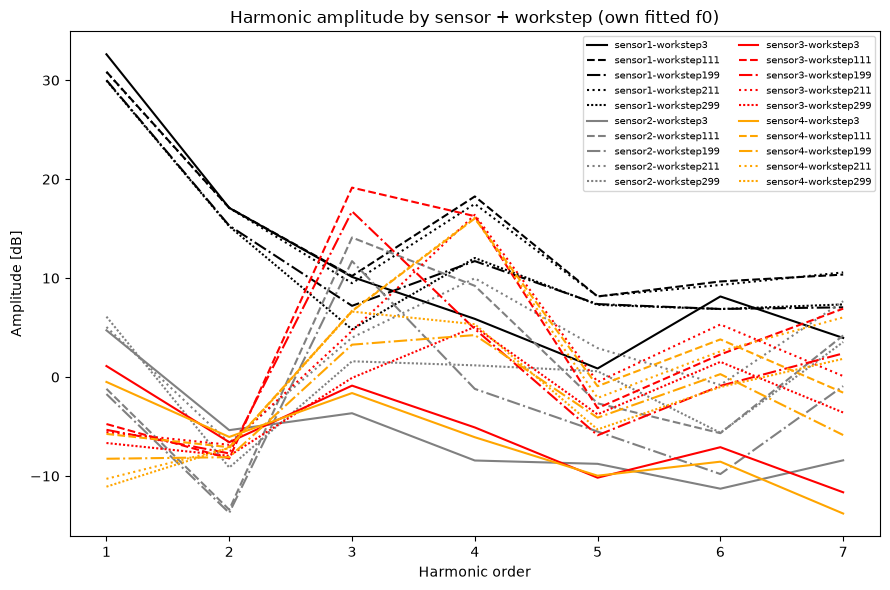

In [7]:
ad.plot_harmonic_amplitudes(data, max_frequency_hz=500)

This figure pins down what's specifically unusual about sensor 1: it's louder at harmonic orders 1-2 and converges with sensors 2-4 by order ~4-5 — amplified low-order harmonics (consistent with a mounting/resonance difference), not extra or shifted peaks. Band energy confirms the same pattern concentrates in the 55-95 Hz band:

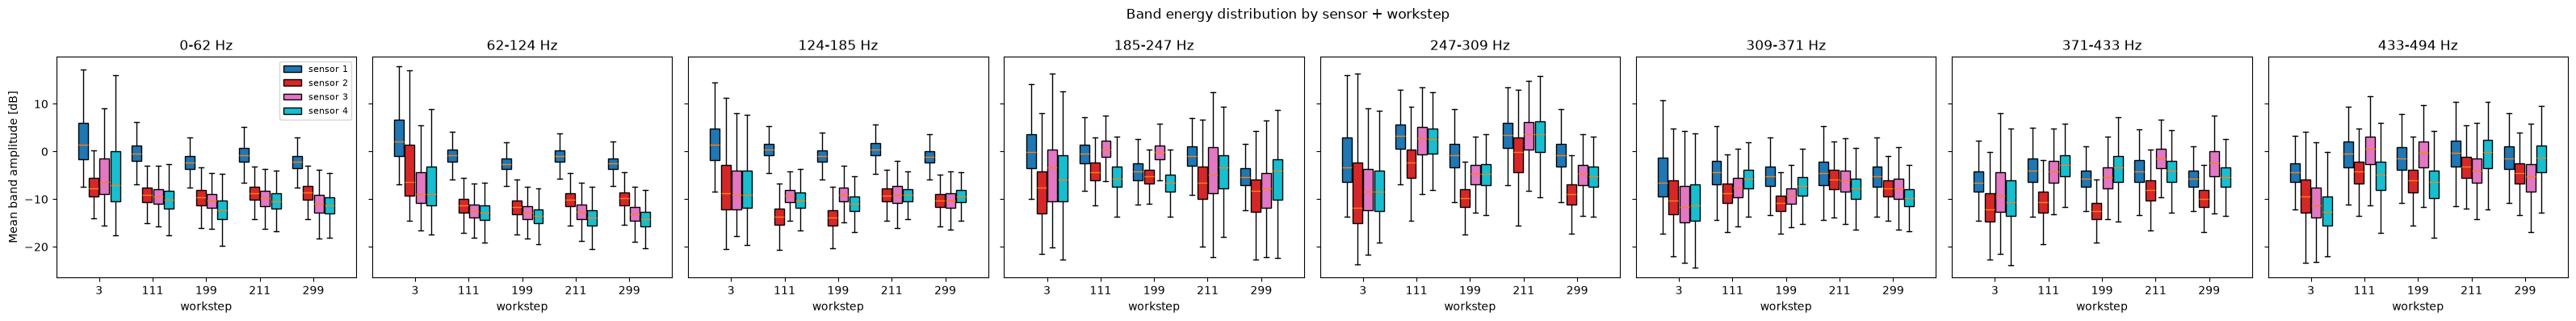

In [8]:
ad.plot_band_energy(data, n_bands=8, max_frequency_hz=500)

Band edges here are **equal-width in Hz** (`band_scale="linear"`), not log-spaced. Log bands were tried first, but with 6.1 Hz resolution the lowest log bands got only 1-2 bins each — barely an average, and not a fair comparison against the ~34-bin top band. Equal-width bins make every panel average roughly the same number of bins, which matters for comparing box-plot spreads across panels.

## 4. Individual trials and per-sensor baseline

Mean spectra hide trial-to-trial variability. Plotting a sample of individual spectra alongside their mean exposes it directly:

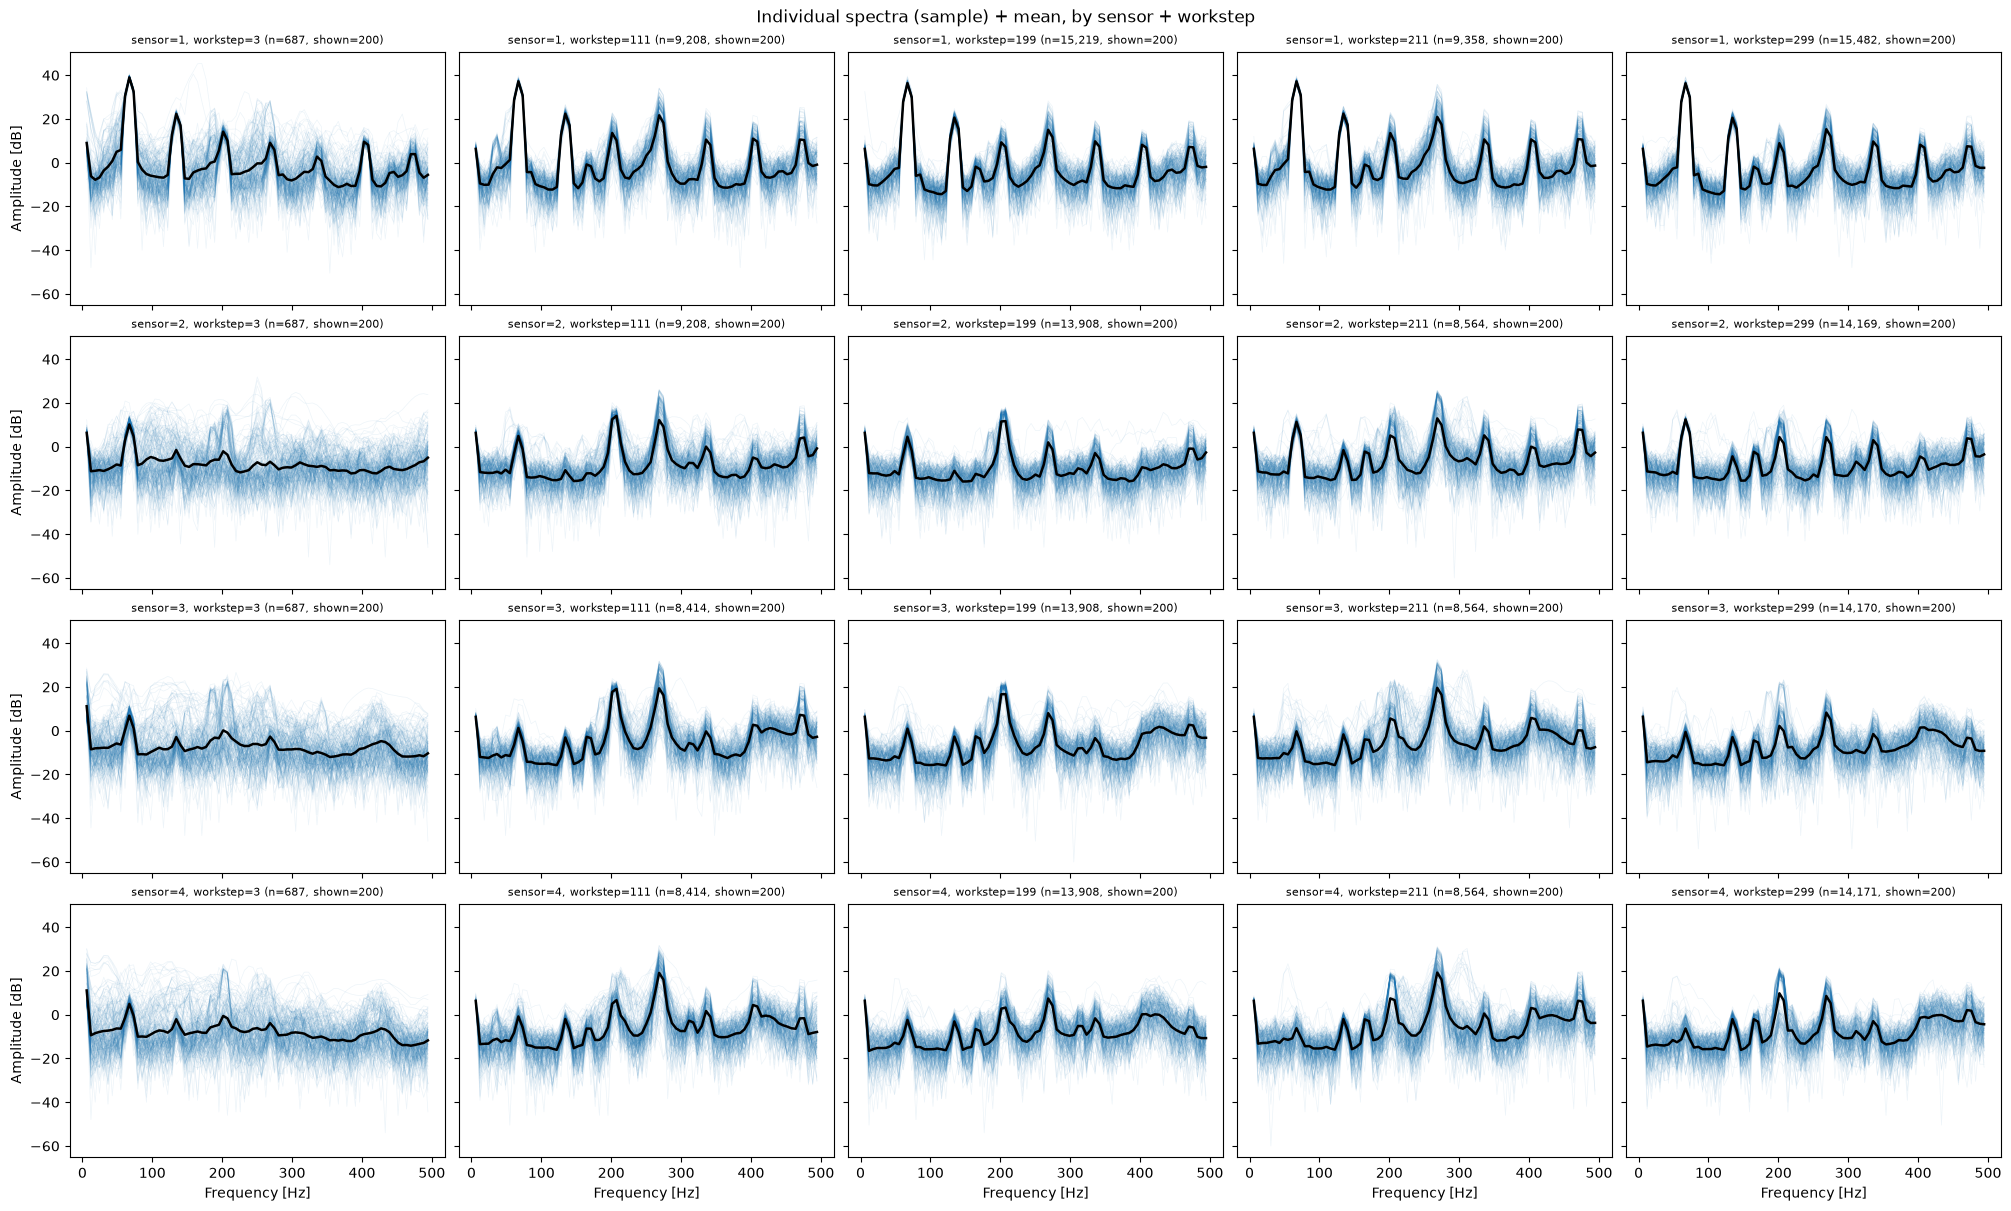

In [9]:
ad.plot_individual_spectra(data, max_frequency_hz=500)

Sensors 2-4 show occasional high-amplitude transient spikes (~270 Hz) that the mean line completely smooths over — the direct motivation for the per-trial anomaly scoring in section 6. Subtracting each sensor's own workstep-3 (warmup) mean spectrum isolates what changes across worksteps from what's always present for that sensor:

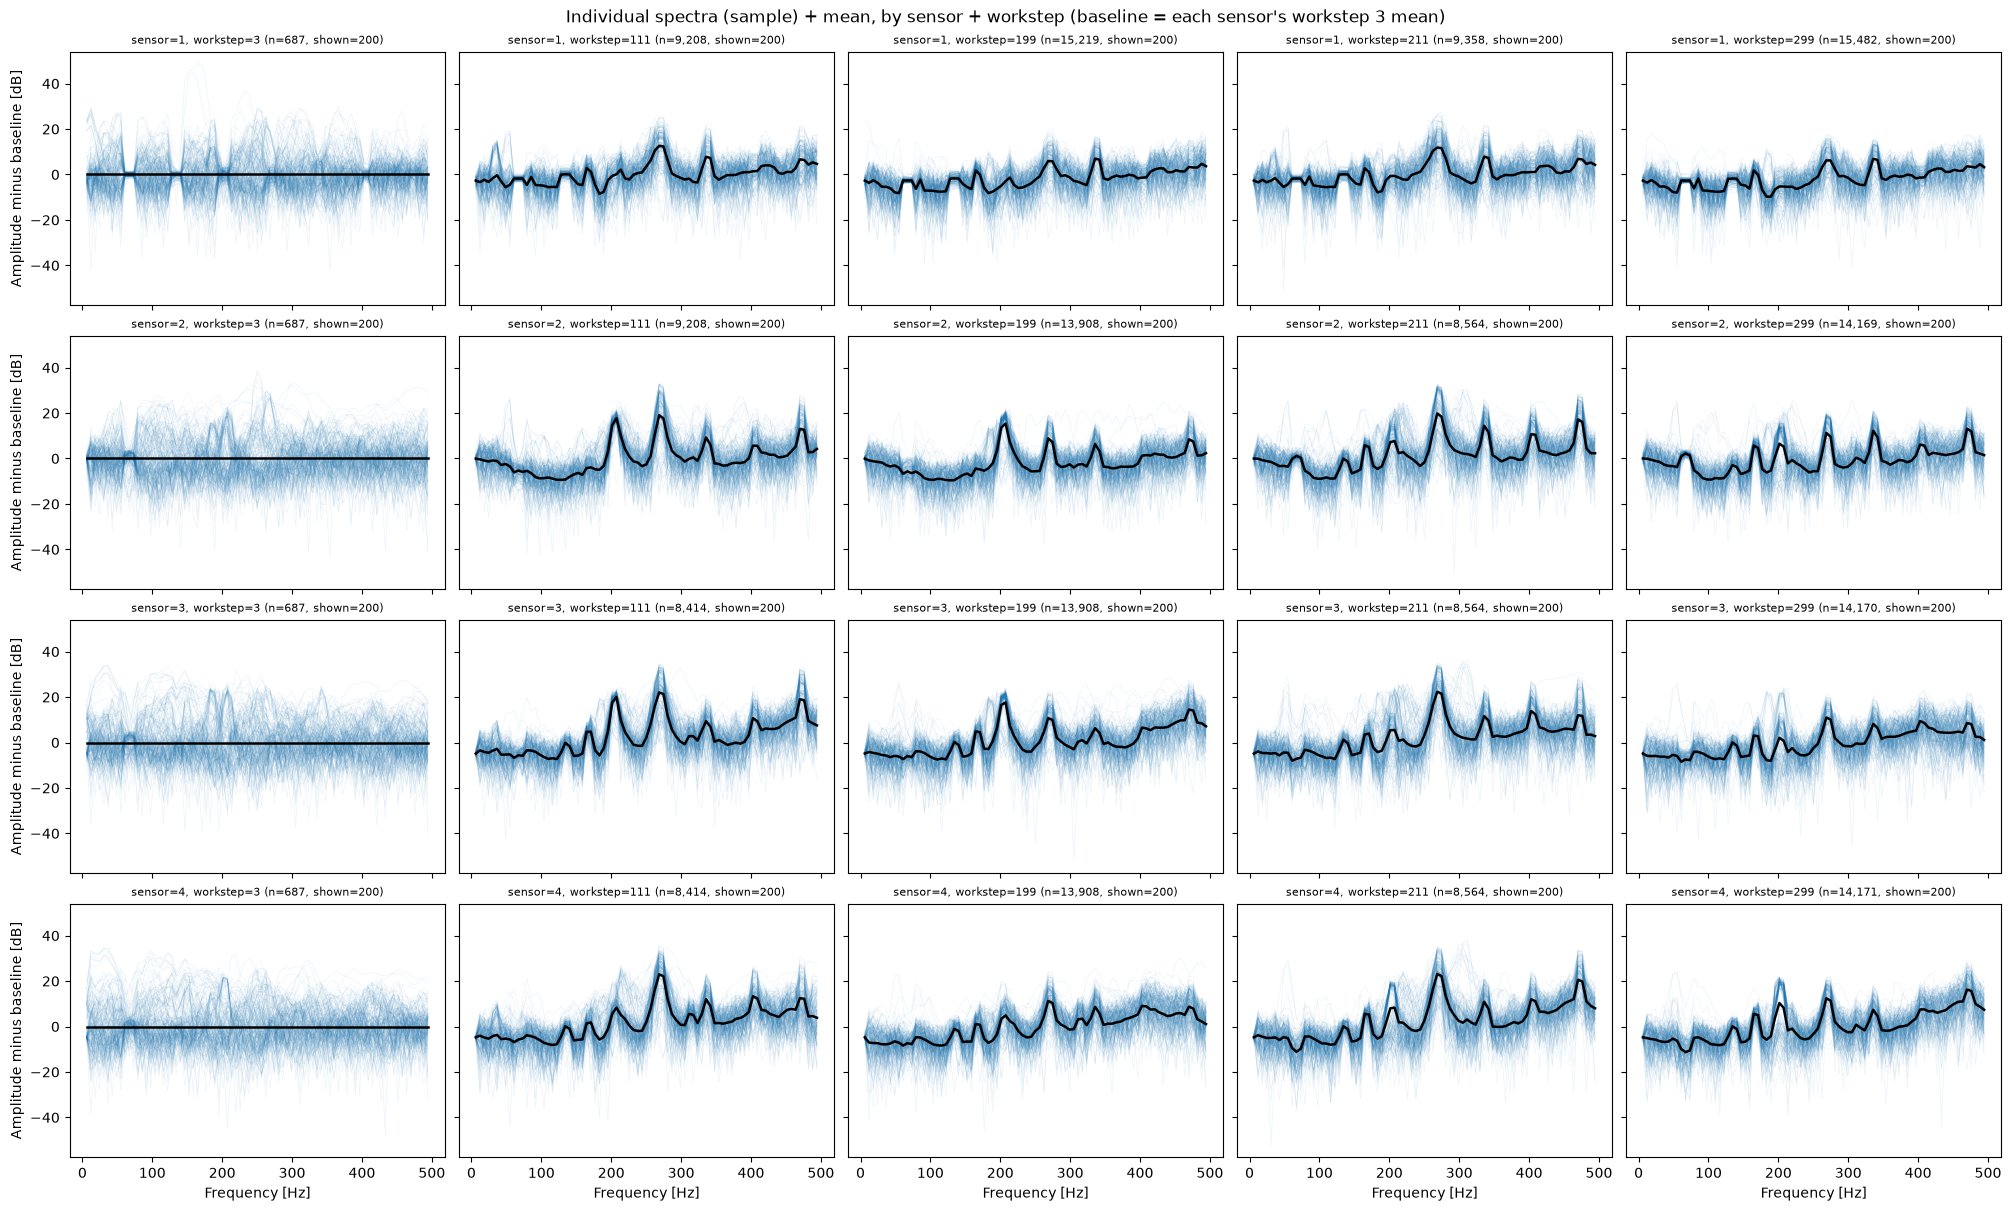

In [10]:
ad.plot_individual_spectra(data, max_frequency_hz=500, subtract_baseline=True)

## 5. Connectivity matrix — grouping without clustering

Rather than run a clustering algorithm, groups are compared directly: each sensor+workstep group's mean spectrum is treated as a mass distribution over frequency, and the pairwise Wasserstein distance between group means is shown as a heatmap (see `notebooks/wasserstein_distance.ipynb` for what that distance means and why it's a sensible choice here).

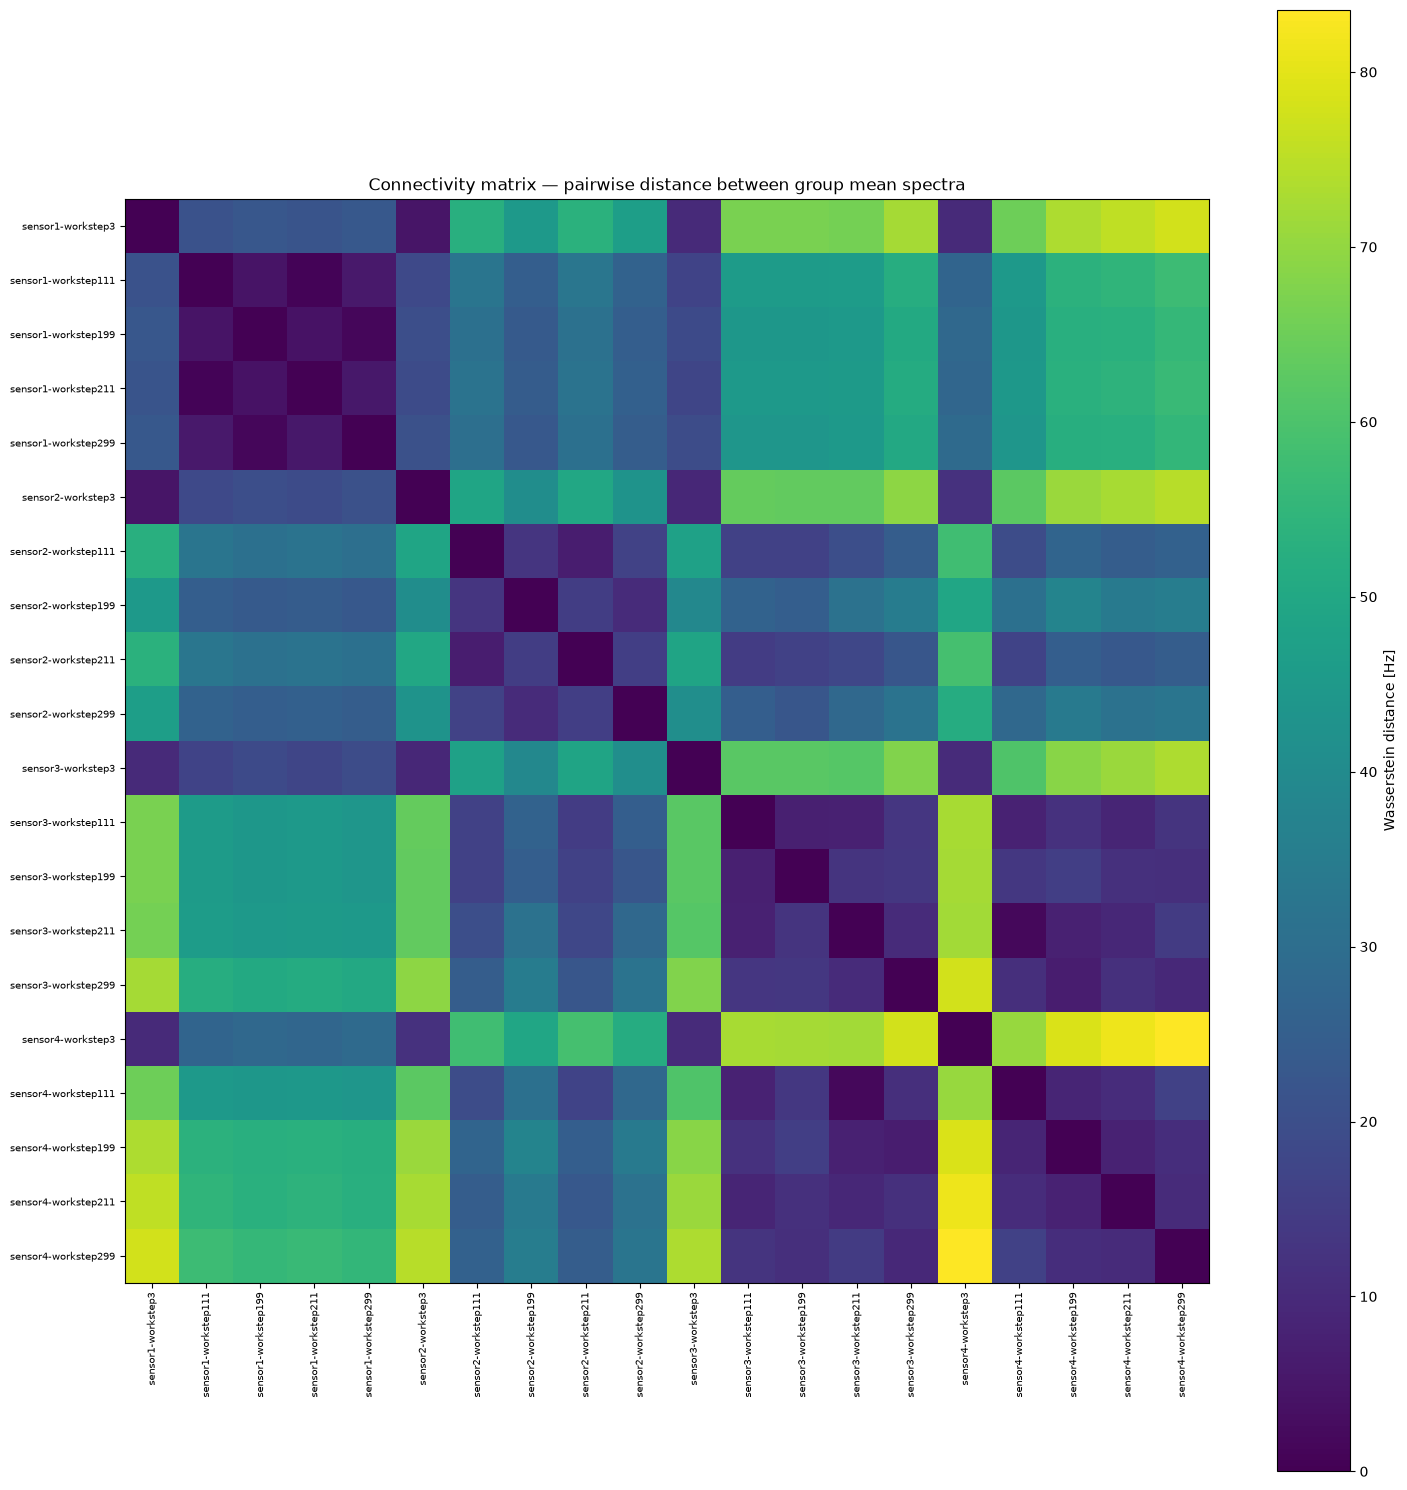

In [11]:
ad.plot_connectivity_matrix(data, max_frequency_hz=500)

Sensor 1's worksteps cluster tightly and sit apart from sensors 2-4; workstep 3 is a visibly distinct block across *every* sensor, consistent with it being an unsupervised warmup step rather than a normal grinding operation. Excluding it gives a cleaner comparison of the four "real" worksteps (16x16 instead of 20x20):

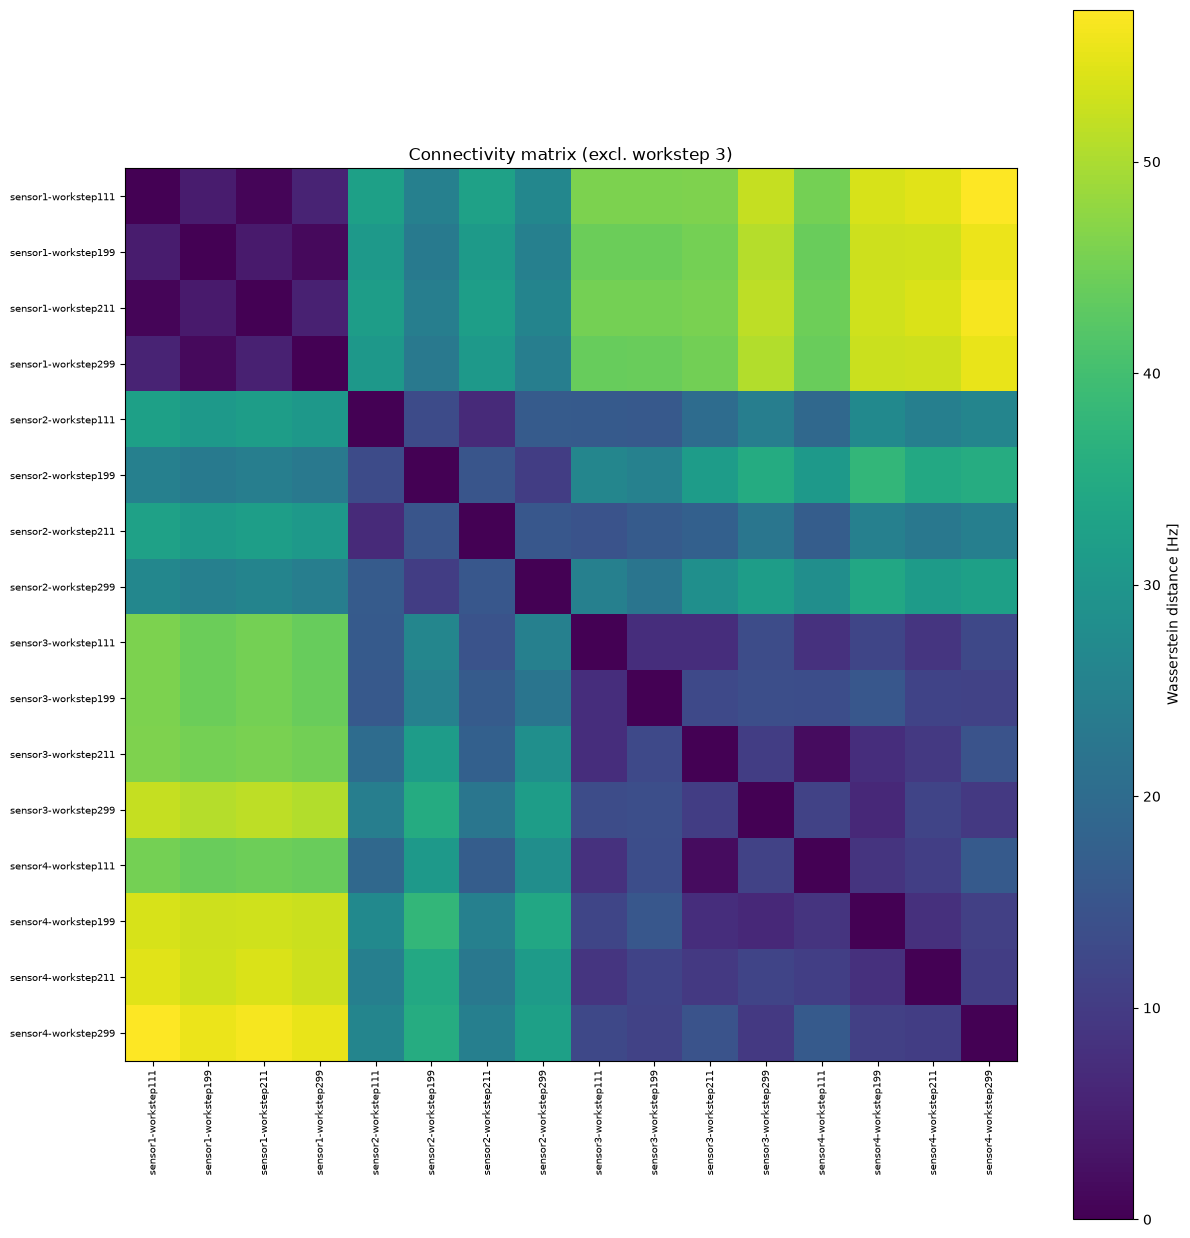

In [12]:
ad.plot_connectivity_matrix(
    data[data["workstep"] != 3],
    max_frequency_hz=500,
    title="Connectivity matrix (excl. workstep 3)",
)

## 6. Anomaly scoring: three ways to define "weird"

No usable ground-truth fault label exists in this dataset (`Alarmlevel` is a configuration artifact, not a severity label — section 1). "Abnormal" is therefore self-defined: for each sensor+workstep group, `ad.compute_shape_anomaly_scores` computes every trial's Wasserstein distance to its own group's mean spectrum, then flags outliers. Three thresholding rules were compared on the same underlying distances:

- **top 1% per group** (percentile) — exact 1% in every group by construction
- **top 5% per group** (percentile) — same idea, a looser cut
- **mean + 3×std per group** (statistical outlier) — rate varies naturally per group instead of being forced

In [13]:
scored_1pct = ad.compute_shape_anomaly_scores(data, max_frequency_hz=500, top_pct=1.0)
scored_5pct = ad.compute_shape_anomaly_scores(data, max_frequency_hz=500, top_pct=5.0)
scored_std = ad.compute_shape_anomaly_scores(data, max_frequency_hz=500, threshold_method="std", n_std=3.0)

for name, s in [("top 1%", scored_1pct), ("top 5%", scored_5pct), ("mean+3std", scored_std)]:
    print(f"{name:12s} positive rate: {s['label'].mean():.3%}  ({s['label'].sum():,} / {len(s):,})")

top 1%       positive rate: 1.005%  (1,890 / 187,977)
top 5%       positive rate: 5.006%  (9,410 / 187,977)
mean+3std    positive rate: 1.229%  (2,311 / 187,977)


The top-1% version is used for the classifier in sections 7-8 (the other two are compared in `results.md`, with the 5% version turning out to give the best classifier results — see the summary at the end). Plotting the score over time, and overlaying only the flagged trials on the spectra, confirms the method catches more than one kind of anomaly: both amplitude spikes and genuine sensor-dropout readings (spectra with a near-zero bin, floored to ≈-240 dB in the dB conversion).

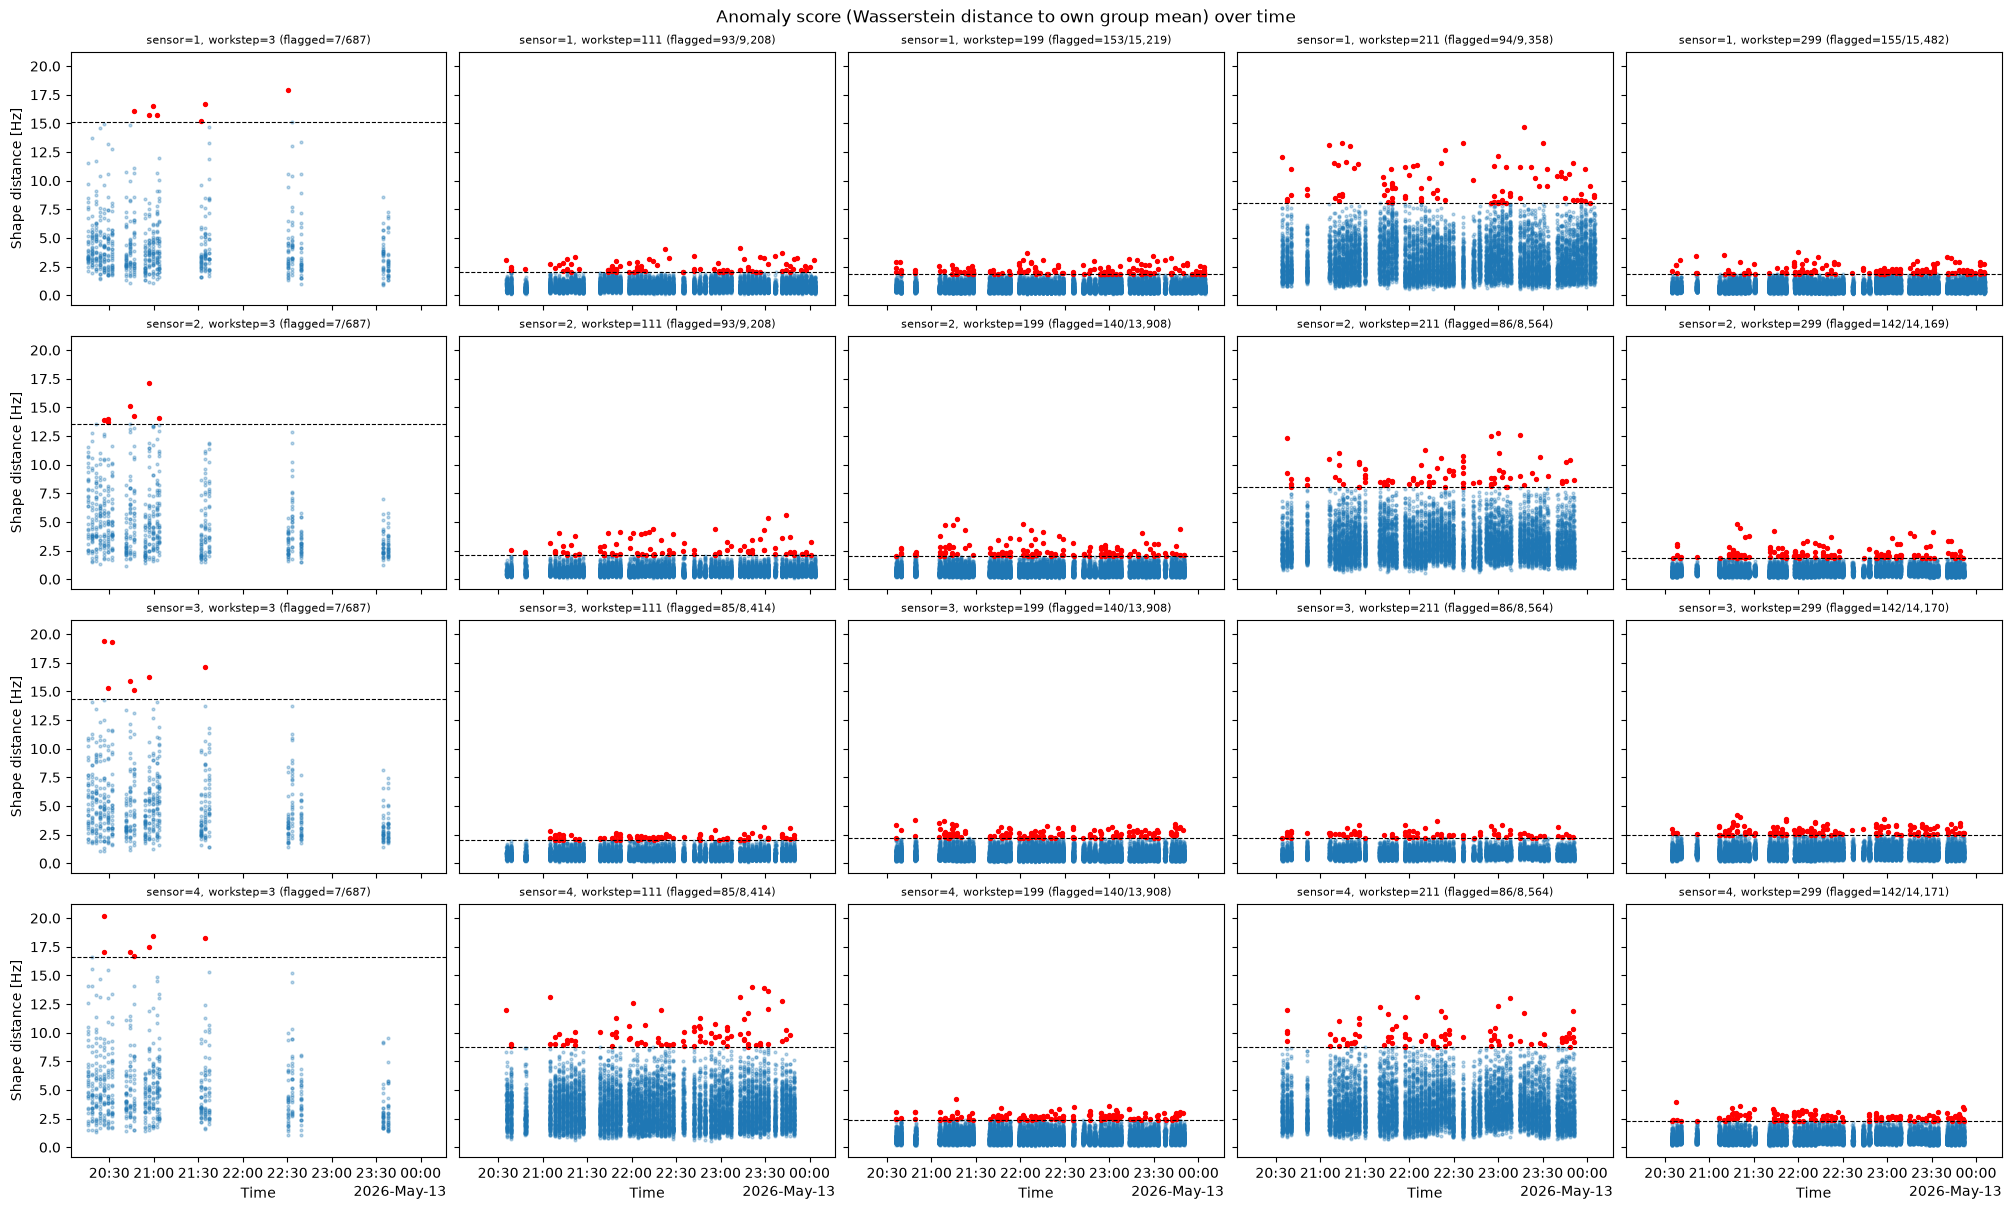

In [14]:
ad.plot_anomaly_scores(scored_1pct)

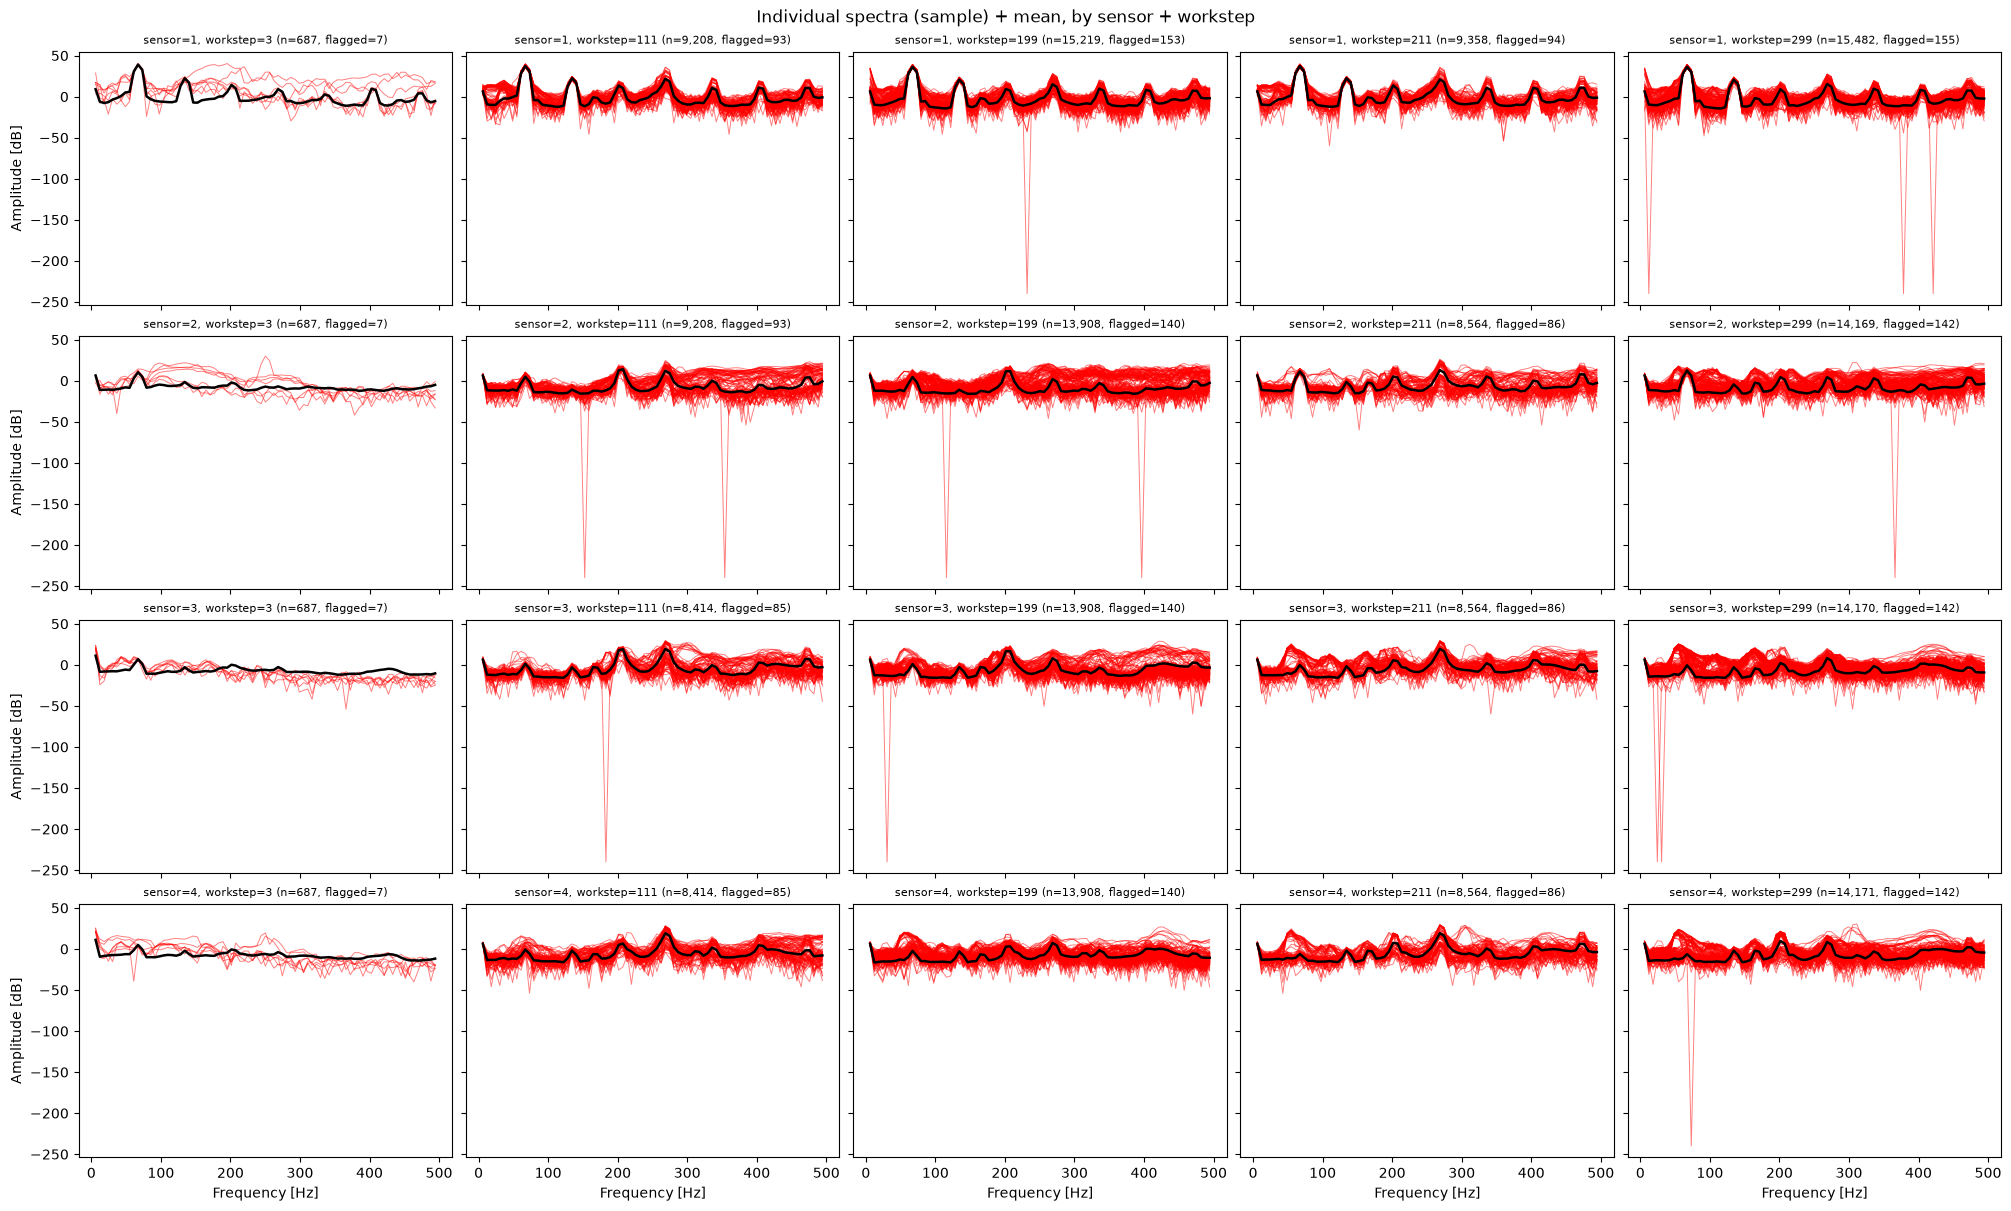

In [15]:
ad.plot_individual_spectra(scored_1pct, max_frequency_hz=500, highlight_col="label")

## 7. Classifier: feature selection

The goal: predict the label directly from the spectrum, without needing a Wasserstein distance to a group mean at inference time. `ad.train_lda_classifier` builds its feature matrix from two pieces:

1. **Raw dB spectrum bins** (≤500 Hz) — deliberately "vanilla", no engineered features (no band energies, no harmonic amplitudes), to establish a baseline before adding complexity.
2. **One-hot sensor + workstep** — added after a first pass with spectrum-only features showed the model couldn't distinguish "normal for group A" from "abnormal for group B": the label is defined *relative to each group's own mean*, but the model only saw absolute dB values with no group identity. Adding group membership as an explicit feature is the minimal fix for that blind spot.

The model itself is a **shrinkage LDA** (`solver="lsqr", shrinkage="auto"`, Ledoit-Wolf) rather than plain LDA — a safer default with no real downside. It made essentially no difference to the numbers below (this dataset's training sets have thousands of samples per class against only 90 features, so the covariance estimate was already well-conditioned and the estimated shrinkage intensity is near zero), but it's a free improvement worth keeping in general.

In [16]:
cols = ad._spectrum_cols(scored_1pct)
freqs = ad._frequencies_for_cols(cols, 6.103515625)
cols, freqs = ad._apply_max_frequency(cols, freqs, 500)
print(f"{len(cols)} spectrum bins (up to {freqs.max():.0f} Hz) + one-hot sensor (4) + one-hot workstep (5) = {len(cols) + 9} features")

81 spectrum bins (up to 494 Hz) + one-hot sensor (4) + one-hot workstep (5) = 90 features


## 8. Training approach

Three design decisions, each motivated by a specific problem hit along the way.

**(a) Causal train/test split.** Consecutive spectra are highly autocorrelated (~150 ms apart), so a random shuffle risks near-duplicate trials landing on both sides of the split. `causal_split=True` (default) instead trains on each group's earlier trials and tests on its later ones — a real test of predicting *future* anomalies from *past* patterns, not just interpolating within a shuffled sample.


Shrinkage-LDA classifier — 81 raw dB bins + 9 sensor/workstep dummies, causal (time-ordered per group) split, label positive rate: 1.005% (test set: 0.961%)
              precision    recall  f1-score   support

     label=0       0.99      0.99      0.99     55864
     label=1       0.20      0.33      0.25       542

    accuracy                           0.98     56406
   macro avg       0.60      0.66      0.62     56406
weighted avg       0.99      0.98      0.98     56406



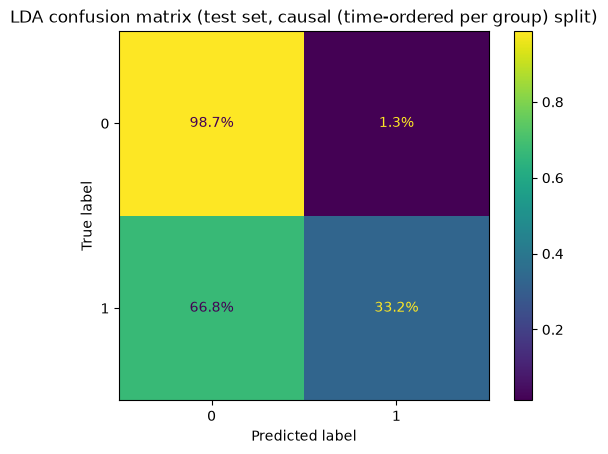

In [17]:
ad.train_lda_classifier(scored_1pct, max_frequency_hz=500, causal_split=True);

For comparison, the random-split version below scores almost identically — the autocorrelation-leakage concern didn't turn out to inflate results much in this particular dataset. Causal is still kept as the default, since it's the methodologically honest choice regardless of whether it happens to matter here.


Shrinkage-LDA classifier — 81 raw dB bins + 9 sensor/workstep dummies, random (stratified) split, label positive rate: 1.005% (test set: 1.005%)
              precision    recall  f1-score   support

     label=0       0.99      0.99      0.99     55827
     label=1       0.22      0.33      0.26       567

    accuracy                           0.98     56394
   macro avg       0.61      0.66      0.63     56394
weighted avg       0.99      0.98      0.98     56394



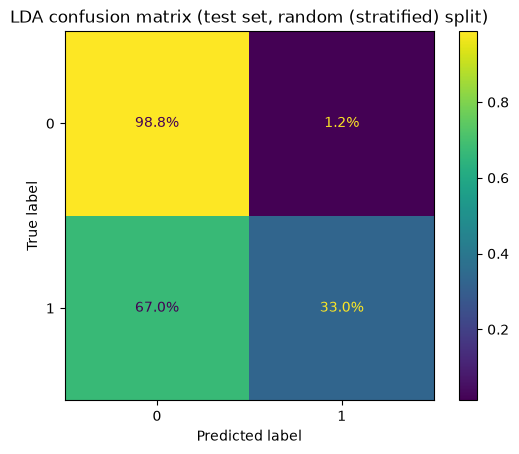

In [18]:
ad.train_lda_classifier(scored_1pct, max_frequency_hz=500, causal_split=False);

**(b) Class balancing.** The label is ~99:1 imbalanced by construction (`top_pct=1.0`). Fitting on the raw imbalance starves the minority class. The approach tried: repeat 5 times — randomly undersample the majority class down to the minority count *in the training fold only* (the test fold is never touched, so evaluation stays honest), fit a fresh model each time, and average the resulting metrics. Averaging over repeats reduces the luck-of-the-draw variance from any single random undersample.

Naively doing this at the default `P>0.5` cutoff was actively harmful: precision on the anomalous class collapsed to 0.04 (recall rose to 0.74, but at the cost of ~10,000 false positives on the normal class). That result is what motivated (c) below, rather than being reproduced here again — see `results.md` for the exact numbers.

**(c) Threshold tuning.** sklearn's default `P>0.5` cutoff only makes sense right after balanced (~50:50) training — it doesn't match the real ~99:1 rate the model faces at test time. The fix: carve a validation slice from the *same held-out/unseen pool as the test set* (stratified, sharing its natural ~99:1 distribution — never a slice of train's own time range, and never the training pool itself), pick the F1-maximizing threshold there via `precision_recall_curve`, and apply that one fixed threshold to the untouched test set for the final numbers.


Shrinkage-LDA classifier — 81 raw dB bins + 9 sensor/workstep dummies, causal (time-ordered per group) split, class-balanced training (1041 x 2 per repeat, averaged over 5 repeats), mean threshold tuned on val: 0.934, label positive rate: 1.005% (test set: 1.004%)
              precision     recall   f1-score    support
label=0            0.99       0.99       0.99    55835.0
label=1            0.20       0.24       0.21      566.0
macro avg          0.59       0.61       0.60    56401.0
weighted avg       0.98       0.98       0.98    56401.0

accuracy                                0.982


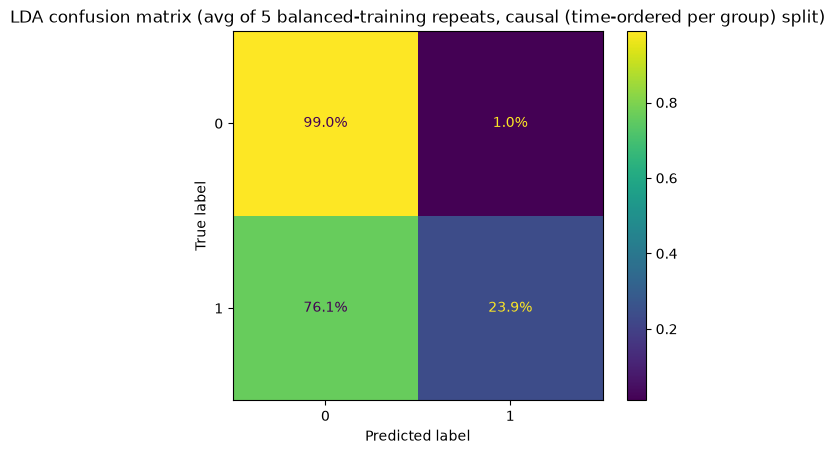

In [19]:
ad.train_lda_classifier(
    scored_1pct, max_frequency_hz=500, causal_split=True,
    balance_classes=True, n_repeats=5, tune_threshold=True,
);

## 9. Summary

| Label definition | Balanced training | Threshold | Precision | Recall | F1 |
|---|---|---|---|---|---|
| top 1% | no | 0.5 (default) | 0.20 | 0.33 | 0.25 |
| top 1% | yes, untuned | 0.5 (default) | 0.04 | 0.74 | 0.07 |
| top 1% | no | tuned (≈0.18) | 0.19 | 0.39 | 0.25 |
| top 1% | yes, tuned | tuned (≈0.93) | 0.20 | 0.24 | 0.21 |
| top 5% | no | tuned (≈0.17) | 0.38 | 0.41 | **0.40** |

(Full table, including the mean+3σ label and random-split variants, is in `results.md`.)

**Key takeaways:**
- Undersampling without threshold tuning is actively harmful — it makes the model far too trigger-happy once evaluated at the default cutoff.
- Threshold tuning alone recovers most of the damage, and on this severity of imbalance (~99:1) actually beats balanced training once the threshold is fixed properly.
- The label definition matters more than any single modeling choice tried: relaxing to top 5% (≈19:1 imbalance instead of ≈99:1) gave the best results overall, simply because there's more signal to learn from and the imbalance itself is less extreme.
- This is still a "vanilla" baseline — raw dB bins, a linear model, evaluated against a self-generated (not independently validated) label. Treat it as a starting point for discussion with whoever owns the machine, not a deployed fault detector.